In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
fraud_df = pd.read_csv("../data/raw/fraud_data.csv")

print("Dataset Shape:", fraud_df.shape)

fraud_df.head()

Dataset Shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


In [4]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [5]:
fraud_df.duplicated().sum()

np.int64(0)

In [6]:
# Convert timestamps to datetime

fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

fraud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(4)
memory usage: 12.7+ MB


## Data Cleaning Summary

- Checked for missing values across all columns.
- No missing values were found.
- Checked for duplicate records.
- No duplicate records were found.
- Converted signup_time and purchase_time from object datatype to datetime format.
- Dataset is clean and ready for exploratory data analysis.

In [7]:
fraud_df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [8]:
fraud_df['class'].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

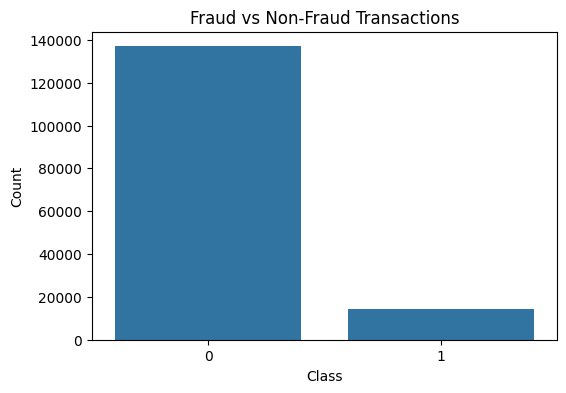

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=fraud_df)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Class')
plt.ylabel('Count')

plt.show()

## Class Imbalance Analysis

The dataset is imbalanced.

- Legitimate transactions (Class 0): 136,961 (90.64%)
- Fraudulent transactions (Class 1): 14,151 (9.36%)

This imbalance may bias machine learning models toward the majority class. Therefore, resampling techniques such as SMOTE will be considered during model training.

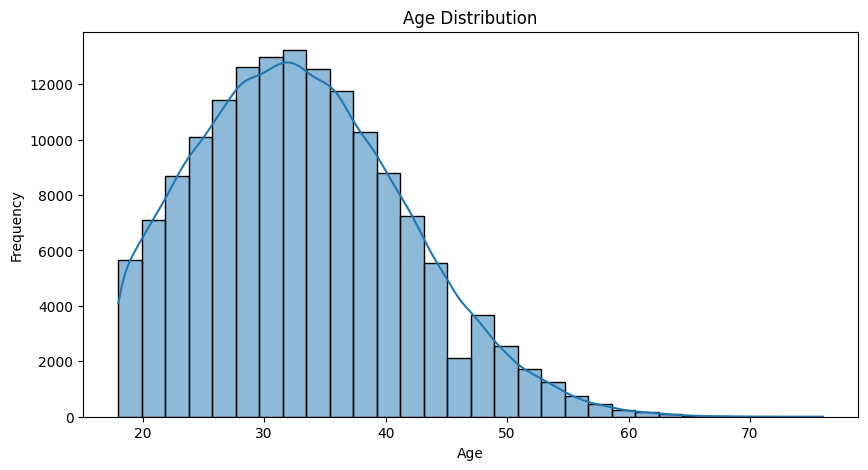

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(fraud_df['age'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

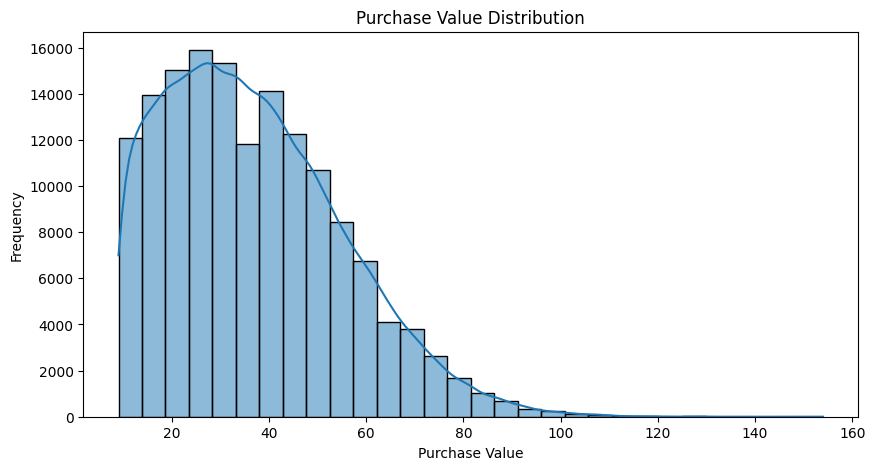

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(fraud_df['purchase_value'], bins=30, kde=True)

plt.title('Purchase Value Distribution')
plt.xlabel('Purchase Value')
plt.ylabel('Frequency')

plt.show()

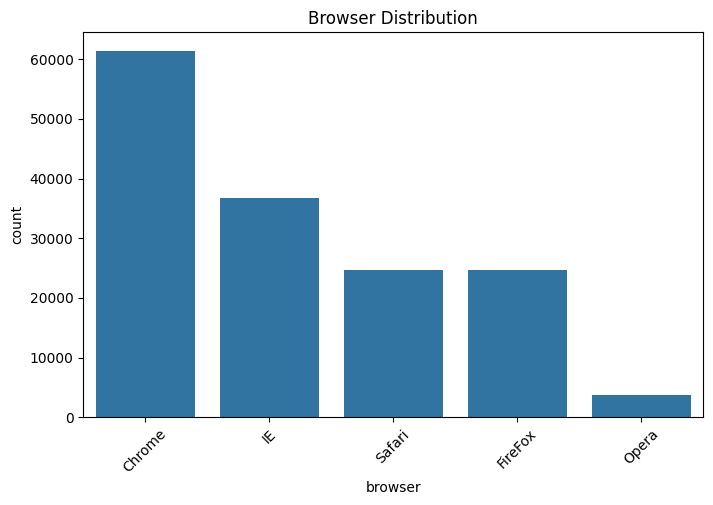

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fraud_df,
    x='browser',
    order=fraud_df['browser'].value_counts().index
)

plt.title('Browser Distribution')
plt.xticks(rotation=45)

plt.show()

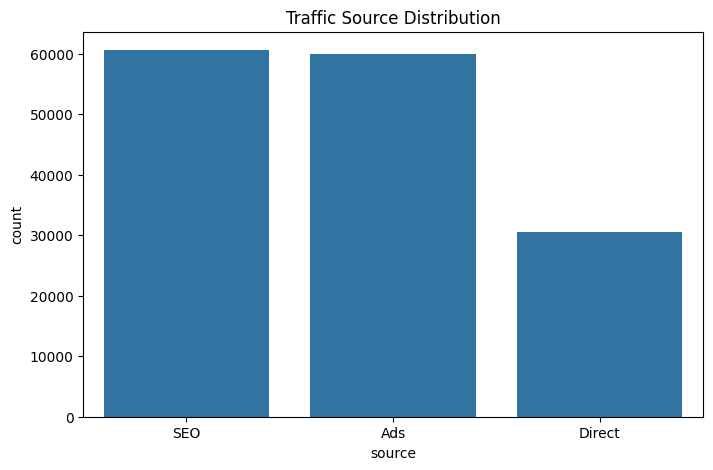

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=fraud_df,
    x='source',
    order=fraud_df['source'].value_counts().index
)

plt.title('Traffic Source Distribution')

plt.show()

## Univariate Analysis Findings

### Browser Distribution
- Chrome is the most commonly used browser among users.
- Other browsers such as Safari, Firefox, and Opera appear less frequently.

### Traffic Source Distribution
- SEO is the dominant traffic acquisition channel.
- Other sources such as Ads and Direct contribute a smaller proportion of traffic.

### Business Insight
- Since most transactions originate from Chrome and SEO traffic, fraud detection systems should pay particular attention to unusual patterns within these high-volume categories.

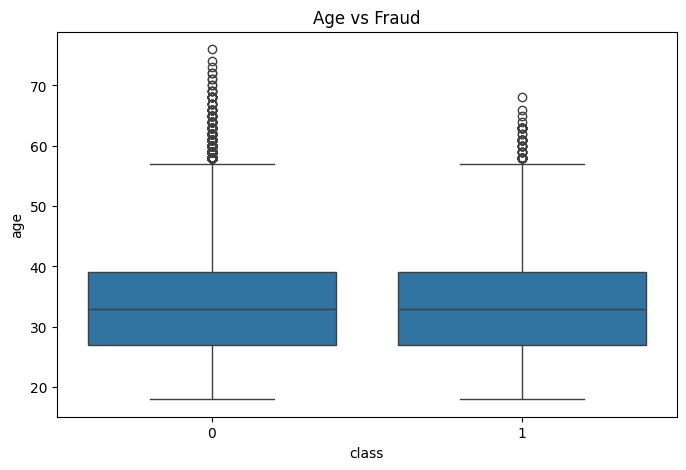

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='class',
    y='age',
    data=fraud_df
)

plt.title('Age vs Fraud')
plt.show()

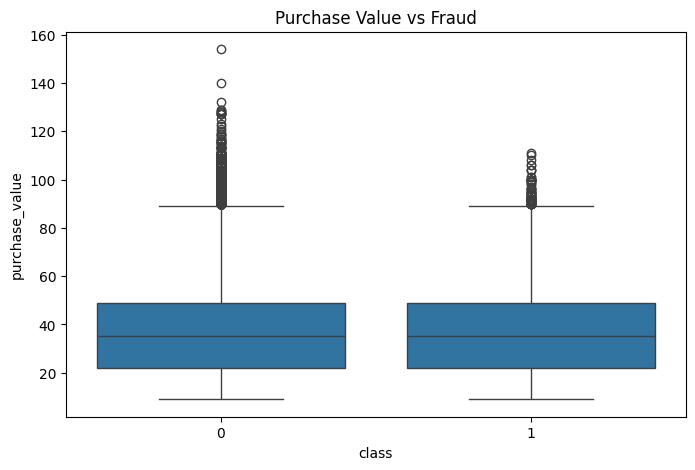

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='class',
    y='purchase_value',
    data=fraud_df
)

plt.title('Purchase Value vs Fraud')
plt.show()

In [16]:
fraud_by_browser = pd.crosstab(
    fraud_df['browser'],
    fraud_df['class'],
    normalize='index'
) * 100

fraud_by_browser

class,0,1
browser,,
Chrome,90.120784,9.879216
FireFox,90.483543,9.516457
IE,91.322460,8.677540
Opera,91.077258,8.922742
Safari,90.979852,9.020148


In [17]:
fraud_by_source = pd.crosstab(
    fraud_df['source'],
    fraud_df['class'],
    normalize='index'
) * 100

fraud_by_source

class,0,1
source,,
Ads,90.793407,9.206593
Direct,89.463026,10.536974
SEO,91.071517,8.928483


## Bivariate Analysis Findings

### Fraud Rate by Browser
- Chrome users show the highest fraud rate (9.88%).
- Firefox follows closely with a fraud rate of 9.52%.
- Internet Explorer users have the lowest fraud rate (8.68%).

### Fraud Rate by Traffic Source
- Direct traffic has the highest fraud rate (10.54%).
- Ads traffic has a fraud rate of 9.21%.
- SEO traffic has the lowest fraud rate (8.93%).

### Business Insight
- Transactions originating from Direct traffic channels may require additional monitoring due to their relatively higher fraud rate.
- Browser type appears to have a small relationship with fraud occurrence, although the differences are not large.

In [18]:
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

print(ip_df.shape)

ip_df.head()

(8, 3)


,lower_bound_ip_address,upper_bound_ip_address,country
0,100000000,149999999,United States
1,150000000,199999999,Canada
2,200000000,249999999,United Kingdom
3,250000000,299999999,Germany
4,300000000,349999999,France


In [19]:
fraud_df['ip_address'].describe()

count    1.511120e+05
mean     2.152145e+09
std      1.248497e+09
min      5.209350e+04
25%      1.085934e+09
50%      2.154770e+09
75%      3.243258e+09
max      4.294850e+09
Name: ip_address, dtype: float64

In [20]:
ip_df

,lower_bound_ip_address,upper_bound_ip_address,country
0,100000000,149999999,United States
1,150000000,199999999,Canada
2,200000000,249999999,United Kingdom
3,250000000,299999999,Germany
4,300000000,349999999,France
5,350000000,399999999,Brazil
6,400000000,449999999,India
7,450000000,499999999,Australia


In [21]:
len(ip_df)

8

In [22]:
fraud_df['ip_address'] = fraud_df['ip_address'].astype('int64')

fraud_df['ip_address'].dtype

dtype('int64')

## IP Address Conversion

The ip_address field was converted from float64 to int64 format to prepare it for range-based IP-to-country mapping. Integer representation is required because the country mapping dataset stores IP ranges as integer values.

In [23]:
fraud_df['ip_address'] = fraud_df['ip_address'].astype('int64')

fraud_df['ip_address'].dtype

dtype('int64')

In [24]:
# Time since signup (in hours)

fraud_df['time_since_signup'] = (
    fraud_df['purchase_time'] - fraud_df['signup_time']
).dt.total_seconds() / 3600

# Hour of purchase

fraud_df['hour_of_day'] = fraud_df['purchase_time'].dt.hour

# Day of week

fraud_df['day_of_week'] = fraud_df['purchase_time'].dt.day_name()

fraud_df[
    ['signup_time',
     'purchase_time',
     'time_since_signup',
     'hour_of_day',
     'day_of_week']
].head()

,signup_time,purchase_time,time_since_signup,hour_of_day,day_of_week
0,2015-02-24 22:55:49,2015-04-18 02:47:11,1251.856111,2,Saturday
1,2015-06-07 20:39:50,2015-06-08 01:38:54,4.984444,1,Monday
2,2015-01-01 18:52:44,2015-01-01 18:52:45,0.000278,18,Thursday
3,2015-04-28 21:13:25,2015-05-04 13:54:50,136.690278,13,Monday
4,2015-07-21 07:09:52,2015-09-09 18:40:53,1211.516944,18,Wednesday


## Feature Engineering

The following temporal features were engineered:

- time_since_signup: Time elapsed between user signup and purchase in hours.
- hour_of_day: Hour when the transaction occurred.
- day_of_week: Day on which the transaction occurred.

These features help capture temporal fraud patterns and user behavior.

In [25]:
# Transaction velocity based on device usage

fraud_df['transaction_velocity'] = (
    fraud_df.groupby('device_id')['device_id']
    .transform('count')
)

fraud_df[['device_id', 'transaction_velocity']].head()

,device_id,transaction_velocity
0,QVPSPJUOCKZAR,1
1,EOGFQPIZPYXFZ,1
2,YSSKYOSJHPPLJ,12
3,ATGTXKYKUDUQN,1
4,NAUITBZFJKHWW,1


In [26]:
fraud_df['transaction_velocity'].describe()

count    151112.000000
mean          1.684367
std           2.616954
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          20.000000
Name: transaction_velocity, dtype: float64

## Transaction Velocity Feature

A transaction velocity feature was created by counting the number of transactions associated with each device_id.

Higher transaction velocity may indicate suspicious behavior because fraudsters often perform multiple transactions using the same device within a short period.

In [27]:
fraud_df['transaction_velocity'] = (
    fraud_df.groupby('device_id')['device_id']
    .transform('count')
)

fraud_df['transaction_velocity'].describe()

count    151112.000000
mean          1.684367
std           2.616954
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          20.000000
Name: transaction_velocity, dtype: float64

## Transaction Velocity Analysis

The transaction velocity feature represents the number of transactions associated with each device.

Key observations:
- Most devices are associated with a single transaction.
- Some devices are associated with multiple transactions.
- The maximum observed transaction velocity is 20 transactions per device.

High transaction velocity may indicate suspicious activity and can be useful for fraud detection.